# Clustering: K-Means, Métricas y Limitaciones Geométricas

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/13_kmeans_y_sus_limitaciones.ipynb)

## Objetivos


- Comprender el funcionamiento interno del algoritmo K-Means y su objetivo matemático (minimizar la inercia).
- Desarrollar **criterio de ingeniería** para determinar el número óptimo de clusters ($K$) combinando múltiples métricas (Elbow, Silhouette, Davies-Bouldin).
- Demostrar visualmente las limitaciones geométricas de K-Means (fracaso ante varianzas desiguales, anisotropía y tamaños dispares).
- Introducir la necesidad de algoritmos más avanzados (GMM, DBSCAN) para topologías complejas.



## Prerrequisitos


- Entendimiento de distancias geométricas (Euclidiana).
- Haber completado: [Manifold Learning: Desenrollando Datos con t-SNE y UMAP](12_manifold_learning_tsne.ipynb).

---



## Configuración del Entorno


In [ ]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

## Introducción Teórica



Hasta ahora, en los problemas de clasificación, teníamos una variable objetivo ($y$) que nos decía la respuesta correcta (ej. "Fraude" o "Normal"). El algoritmo aprendía a separar esas clases.

Pero, ¿qué pasa si se tienen una base de datos de `100.000` clientes y el equipo de Marketing nos pide: *"Agrupar a estos clientes en perfiles similares para lanzar campañas personalizadas"*? No hay una respuesta correcta previa.

Esto es **Aprendizaje No Supervisado (Clustering)**.



### El Algoritmo K-Means



K-Means es el rey indiscutible del clustering por su extrema velocidad y simplicidad. Funciona así:
1. El ingeniero define cuántos grupos quiere encontrar ($K$).
2. El algoritmo coloca $K$ puntos aleatorios en el espacio (los **Centroides**).
3. Asigna cada dato al centroide más cercano (usando distancia Euclidiana).
4. Recalcula la posición del centroide moviéndolo al centro exacto (el promedio) de todos los datos que le fueron asignados.
5. Repite los pasos 3 y 4 hasta que los centroides dejen de moverse.

El objetivo matemático de K-Means es minimizar la **Inercia** (la suma de las distancias al cuadrado de cada punto a su centroide). Busca que los grupos sean lo más compactos y densos posible.

La siguiente gráfica pretende ilustrar este proceso (las estrellas representan a los centroides y su evolución):

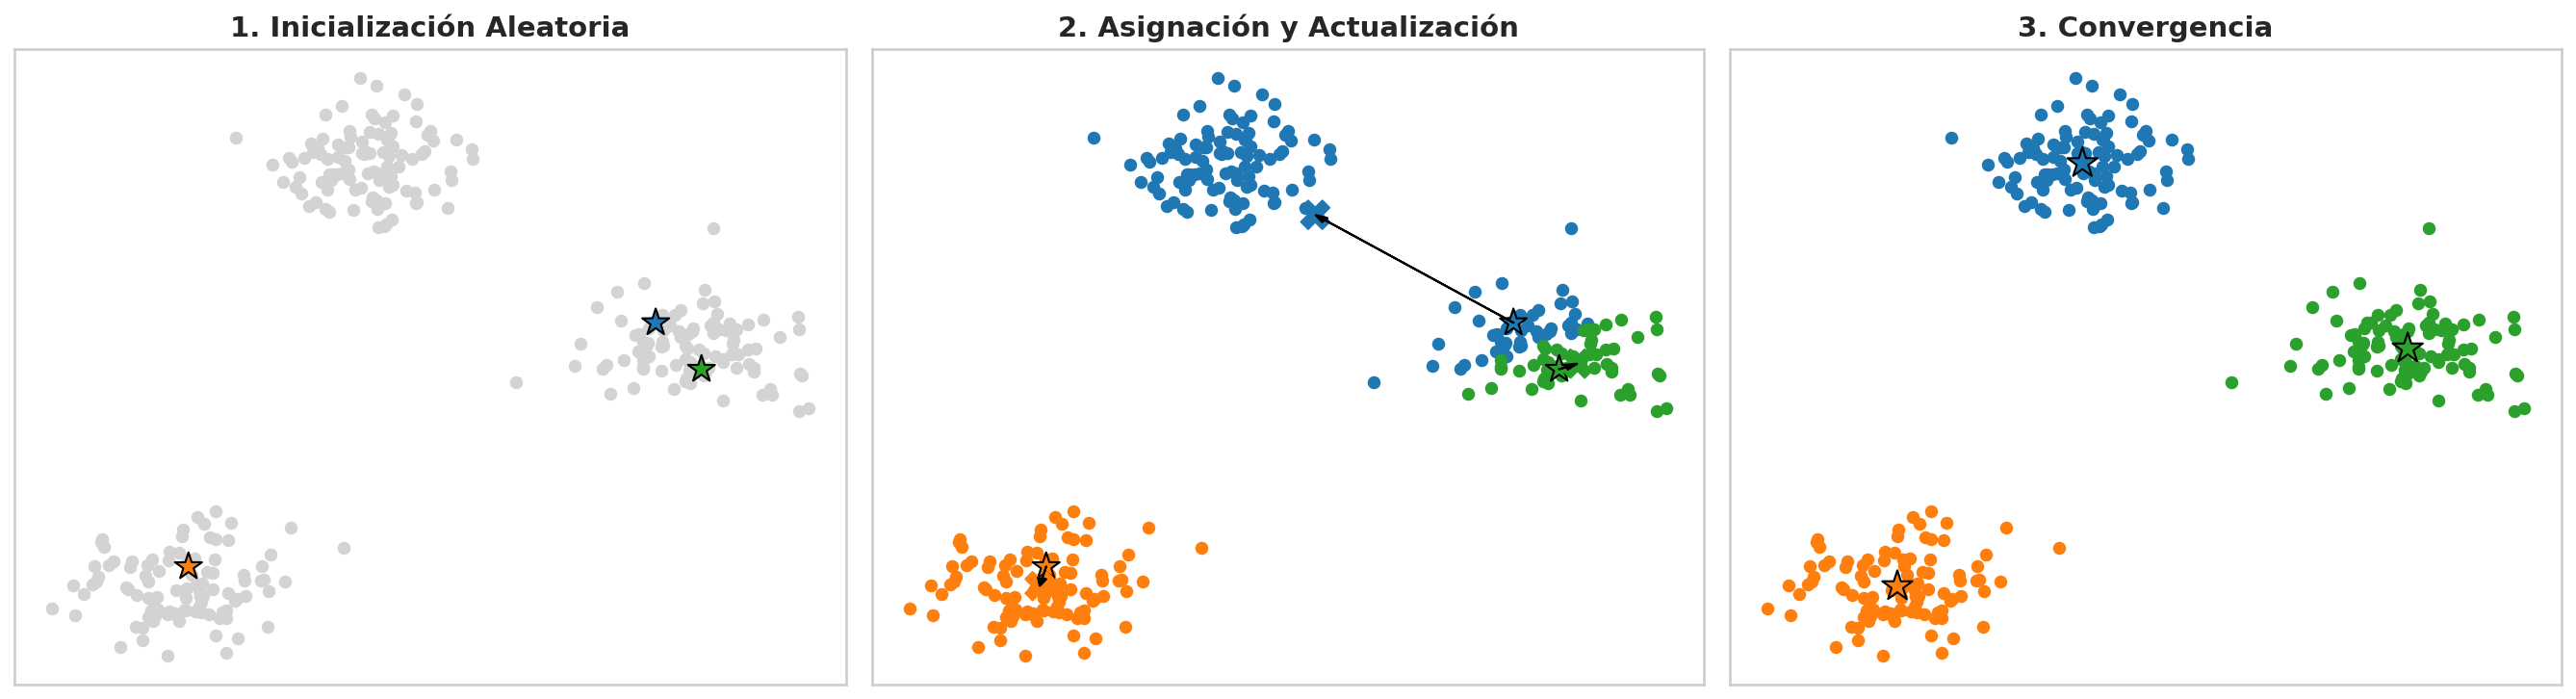

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)

# Datos sintéticos
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.2, random_state=42)

K = 3

# Inicialización aleatoria de centroides
centroids_init = X[np.random.choice(len(X), K, replace=False)]

# === Funciones auxiliares ===
def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def compute_centroids(X, labels, K):
    return np.array([X[labels == k].mean(axis=0) for k in range(K)])

# Iteración 1
labels_1 = assign_clusters(X, centroids_init)
centroids_1 = compute_centroids(X, labels_1, K)

# Iteración hasta convergencia
centroids_final = centroids_1.copy()
for _ in range(10):
    labels = assign_clusters(X, centroids_final)
    centroids_final = compute_centroids(X, labels, K)

labels_final = assign_clusters(X, centroids_final)

# Plot en 3 pasos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green']

# --- Panel 1: Inicialización ---
axes[0].scatter(X[:, 0], X[:, 1], c='lightgray', s=30)
axes[0].scatter(centroids_init[:, 0], centroids_init[:, 1],
                c=colors, s=200, marker='*', edgecolor='black')
axes[0].set_title("1. Inicialización Aleatoria")
axes[0].set_xticks([])
axes[0].set_yticks([])

# --- Panel 2: Asignación + Movimiento ---
for k in range(K):
    axes[1].scatter(X[labels_1 == k][:, 0],
                    X[labels_1 == k][:, 1],
                    c=colors[k], s=30)

axes[1].scatter(centroids_init[:, 0], centroids_init[:, 1],
                c=colors, s=200, marker='*', edgecolor='black')

axes[1].scatter(centroids_1[:, 0], centroids_1[:, 1],
                c=colors, s=200, marker='X')

# Flechas de movimiento
for i in range(K):
    axes[1].arrow(centroids_init[i, 0], centroids_init[i, 1],
                  centroids_1[i, 0] - centroids_init[i, 0],
                  centroids_1[i, 1] - centroids_init[i, 1],
                  color='black', head_width=0.2, length_includes_head=True)

axes[1].set_title("2. Asignación y Actualización")
axes[1].set_xticks([])
axes[1].set_yticks([])

# --- Panel 3: Convergencia ---
for k in range(K):
    axes[2].scatter(X[labels_final == k][:, 0],
                    X[labels_final == k][:, 1],
                    c=colors[k], s=30)

axes[2].scatter(centroids_final[:, 0], centroids_final[:, 1],
                c=colors, s=250, marker='*', edgecolor='black')

axes[2].set_title("3. Convergencia")
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

## Desarrollo e Implementación



Vamos a generar un dataset sintético perfecto para K-Means: 4 grupos esféricos bien separados.



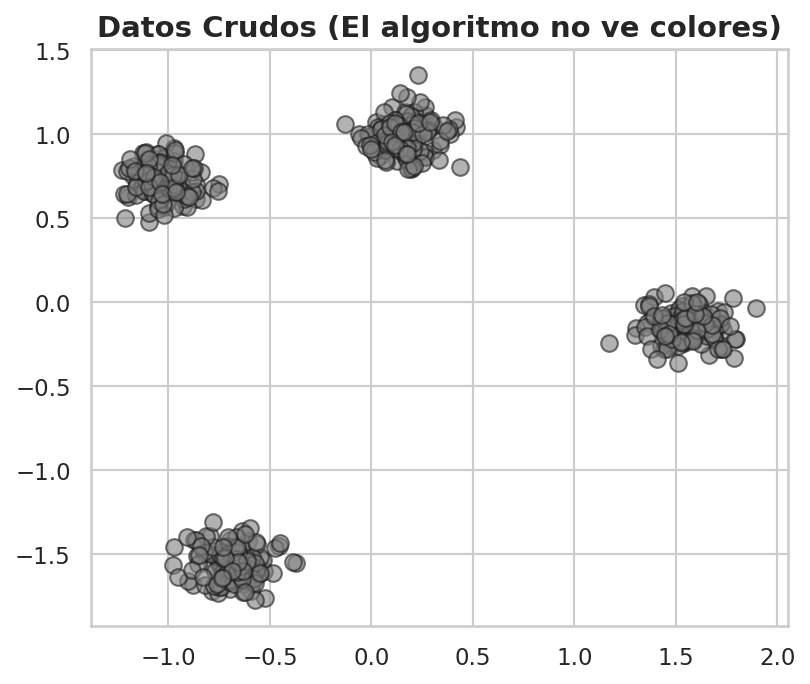

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Generamos datos sintéticos (4 grupos esféricos)
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=42)

# 2. Estandarización (CRÍTICO en Clustering)
# K-Means usa distancias. Si una variable está en miles y otra en decimales,
# la variable grande dominará la distancia y arruinará los grupos.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualizamos los datos crudos (sin etiquetas)
plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c='gray', edgecolors='k', alpha=0.6)
plt.title("Datos Crudos (El algoritmo no ve colores)")
plt.show()

### El Problema de Ingeniería: ¿Cómo elegir K?



En este ejemplo de juguete, vemos claramente 4 grupos. Pero en un dataset real de 50 dimensiones, no podemos graficarlo. Si elegimos un $K$ incorrecto, el algoritmo forzará agrupaciones sin sentido.

Para tomar una decisión informada, los ingenieros no confían en una sola métrica. Entrenamos el modelo con diferentes valores de $K$ (ej. de 2 a 10) y evaluamos tres métricas distintas:

1. **Inercia (Método del Codo / Elbow):** Mide qué tan compactos son los clusters. Siempre baja al aumentar $K$. Buscamos el punto donde la curva hace un "codo" (deja de bajar drásticamente).
2. **Coeficiente de Silhouette:** Mide qué tan similar es un punto a su propio cluster comparado con el cluster vecino más cercano. Va de -1 a 1. **Buscamos el valor más alto (cercano a 1).**
3. **Índice Davies-Bouldin:** Mide la relación entre la dispersión interna del cluster y la separación entre clusters. **Buscamos el valor más bajo.**



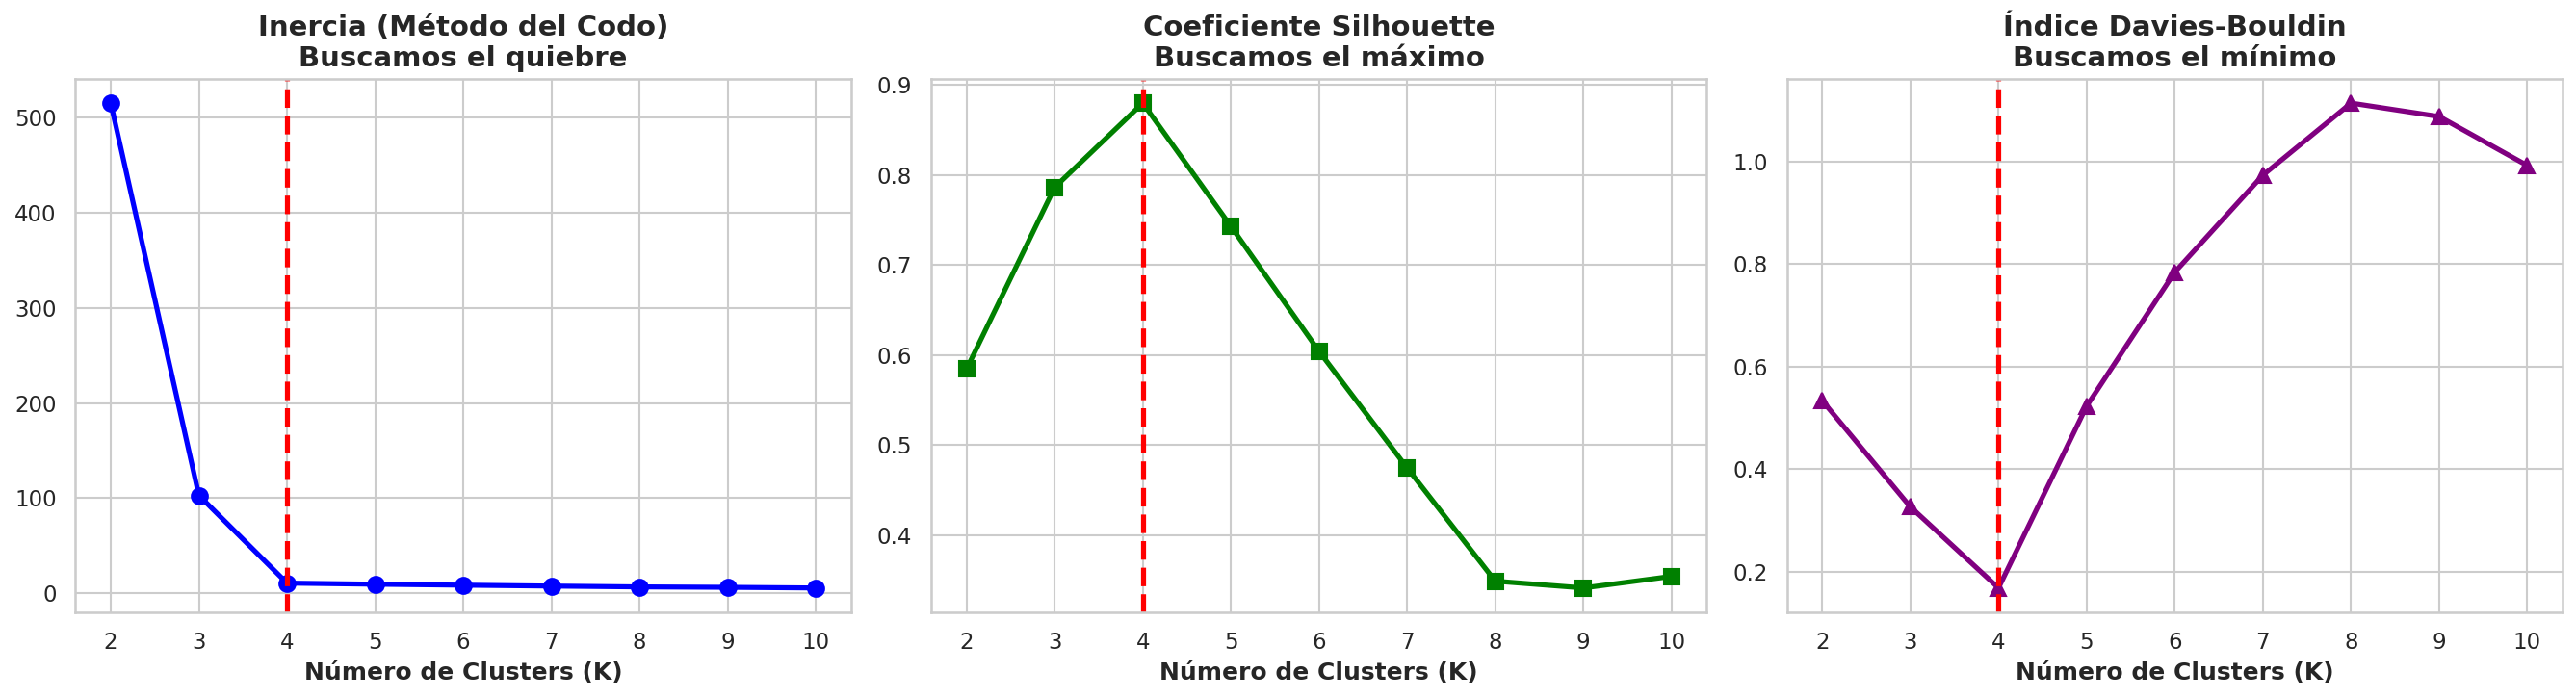

In [ ]:
# Evaluamos K desde 2 hasta 10
rango_k = range(2, 11)
inercias = []
siluetas = []
davies = []

for k in rango_k:
    # n_init=10: Ejecuta el algoritmo 10 veces con centroides iniciales distintos
    # y se queda con el mejor resultado para evitar mínimos locales.
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = kmeans.fit_predict(X_scaled)

    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(X_scaled, etiquetas))
    davies.append(davies_bouldin_score(X_scaled, etiquetas))

# Graficamos las tres métricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Método del Codo
axes[0].plot(rango_k, inercias, marker='o', color='blue')
axes[0].set_title('Inercia (Método del Codo)\nBuscamos el quiebre')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].axvline(x=4, color='red', linestyle='--')

# 2. Silhouette
axes[1].plot(rango_k, siluetas, marker='s', color='green')
axes[1].set_title('Coeficiente Silhouette\nBuscamos el máximo')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].axvline(x=4, color='red', linestyle='--')

# 3. Davies-Bouldin
axes[2].plot(rango_k, davies, marker='^', color='purple')
axes[2].set_title('Índice Davies-Bouldin\nBuscamos el mínimo')
axes[2].set_xlabel('Número de Clusters (K)')
axes[2].axvline(x=4, color='red', linestyle='--')

plt.tight_layout()
plt.show()


**Criterio de Decisión:** Las tres métricas coinciden perfectamente. El codo se forma en $K=4$, Silhouette alcanza su pico máximo en $K=4$, y Davies-Bouldin alcanza su mínimo absoluto en $K=4$. Matemáticamente, 4 es la respuesta correcta.



¿Por qué tantas métricas? En problemas reales... no suele ser tan clara y obvia la elección de $K$. Por lo tanto, es útil tener varios puntos de vista, de modo de sustentar las decisiones.

## ⚠️ Las Limitaciones Geométricas de K-Means



Si K-Means es tan rápido y las métricas son tan claras, ¿por qué necesitamos otros algoritmos?

El problema radica en los **supuestos matemáticos** que hace K-Means:
1. Asume que los clusters son **esféricos** (isotrópicos).
2. Asume que los clusters tienen **varianzas similares** (densidad parecida).
3. Asume que los clusters tienen **tamaños similares** (cantidad de puntos).

Vamos a generar tres datasets que violan estos supuestos y veremos cómo K-Means fracasa, incluso si le damos el $K$ correcto.



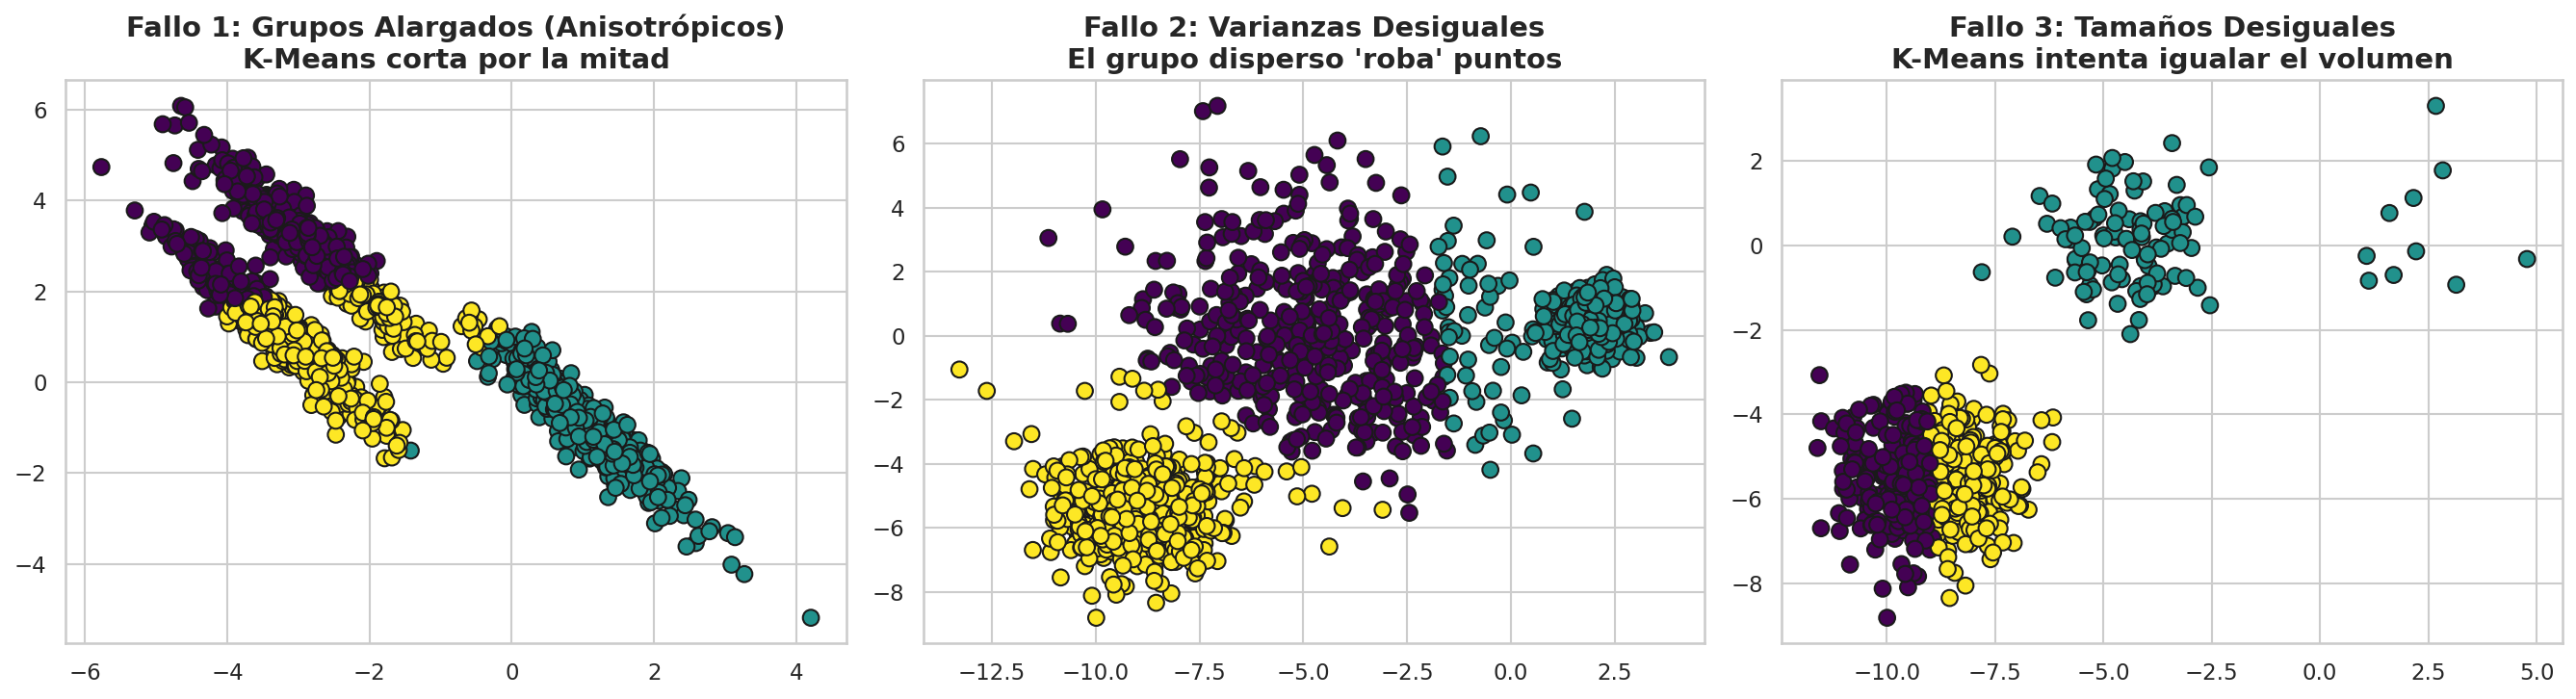

In [ ]:
# Generamos datasets problemáticos
n_samples = 1500
random_state = 170

# 1. Grupos Alargados (Anisotrópicos)
X_blobs, y_blobs = make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X_blobs, transformation)

# 2. Varianzas Desiguales (Un grupo muy denso, otro muy disperso)
X_varied, y_varied = make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state)

# 3. Tamaños Desiguales (Un grupo masivo, dos minúsculos)
X_filtered = np.vstack((X_blobs[y_blobs == 0][:500], X_blobs[y_blobs == 1][:100], X_blobs[y_blobs == 2][:10]))

# Entrenamos K-Means en los tres escenarios (Sabiendo que K=3 es el correcto)
y_pred_aniso = KMeans(n_clusters=3, n_init=10, random_state=random_state).fit_predict(X_aniso)
y_pred_varied = KMeans(n_clusters=3, n_init=10, random_state=random_state).fit_predict(X_varied)
y_pred_filtered = KMeans(n_clusters=3, random_state=random_state).fit_predict(X_filtered) # dejé n_init por defecto, para que se note...

# Visualizamos el desastre
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred_aniso, cmap='viridis', edgecolors='k')
axs[0].set_title("Fallo 1: Grupos Alargados (Anisotrópicos)\nK-Means corta por la mitad")

axs[1].scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred_varied, cmap='viridis', edgecolors='k')
axs[1].set_title("Fallo 2: Varianzas Desiguales\nEl grupo disperso 'roba' puntos")

axs[2].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred_filtered, cmap='viridis', edgecolors='k')
axs[2].set_title("Fallo 3: Tamaños Desiguales\nK-Means intenta igualar el volumen")

plt.tight_layout()
plt.show()

## Resultados y Discusión


Analizar los gráficos superiores. Son la prueba visual de por qué un ingeniero no puede aplicar algoritmos a ciegas:

1. **Grupos Alargados (Izquierda):** K-Means solo entiende de círculos perfectos. Al ver tres "cigarrillos" diagonales, intenta encajar tres círculos sobre ellos, cortando los grupos reales por la mitad.
2. **Varianzas Desiguales (Centro):** El grupo central es muy disperso. K-Means, al basarse puramente en la distancia al centroide, asigna los puntos periféricos del grupo disperso a los grupos densos vecinos, arruinando la frontera real.
3. **Tamaños Desiguales (Derecha):** K-Means tiende a crear clusters del mismo volumen espacial. Si un grupo tiene 500 puntos y otro tiene 10, el centroide del grupo pequeño será "arrastrado" hacia el grupo masivo. Con `n_init` adecuado, esto puede solucionarse hasta cierto punto. Probar de establecer en 10 por ejemplo. Y con eso se "demuestra" su efecto.



### La Solución de Ingeniería



Si los datos (tras proyectarlos con UMAP o PCA) muestran estas formas complejas, K-Means no es la herramienta adecuada.

- Para **Grupos Alargados o Varianzas Desiguales**, la solución matemática es usar **Gaussian Mixture Models (GMM)**, que permite que los clusters tengan formas elípticas y densidades diferentes.
- Para **Formas Arbitrarias** (ej. dos lunas entrelazadas o anillos concéntricos), la solución es abandonar los centroides y usar algoritmos basados en densidad como **DBSCAN**.

## Conexiones y Próximos Pasos


Dominamos K-Means (lo básico al menos), sabemos cómo elegir $K$ de forma robusta y, lo más importante, sabemos cuándo **no** usarlo.

- ➡️ **Siguiente:** En el notebook [Clustering Jerárquico y GMM](14_clustering_jerarquico_y_gmm.ipynb), resolvemos los problemas geométricos que acabamos de exponer. Aprendemos a modelar elipses con GMM y descubrimos cómo el Clustering Jerárquico nos permite agrupar datos sin tener que adivinar $K$ de antemano, usando Dendrogramas.
- 🔄 **Relacionado:** Si los datos tienen muchos *outliers* (valores atípicos), K-Means sufrirá porque los centroides se verán arrastrados por esos puntos extremos. Una alternativa robusta es **K-Medoids**, que utiliza puntos reales del dataset como centros en lugar de promedios matemáticos.

## Referencias


1. MacQueen, J. (1967). *Some methods for classification and analysis of multivariate observations*. In Proceedings of the fifth Berkeley symposium on mathematical statistics and probability (Vol. 1, No. 14, pp. 281-297).
2. [Scikit-Learn: Demonstration of k-means assumptions](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_assumptions.html)

---


## Entorno de Ejecución


In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
